In [35]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [36]:
X,y = make_classification(
    n_samples=500,
    n_features=5,
    n_classes=2,
    n_redundant=1,
    n_informative=3,
    random_state=42
)

In [37]:
X = np.transpose(X)

In [38]:
X[0].shape

(500,)

In [39]:
dictionary = {
    "f1":X[0],
    "f2":X[1],
    "f3":X[2],
    "f4":X[3],
    "f5":X[4],
    "label":y
}

In [41]:
df = pd.DataFrame(dictionary)

In [42]:
df.head()

,f1,f2,f3,f4,f5,label
0,-1.299565,0.608232,-1.518449,1.004770,1.495378,1
1,-0.273844,1.358806,1.194674,1.223679,2.467322,1
2,-2.510600,-2.423153,-0.768365,2.434551,1.227190,0
3,0.374002,-0.794579,-0.093434,-1.252782,-2.123091,0
4,0.378860,1.193772,-0.187534,0.633405,1.692101,1


In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   f1      500 non-null    float64
 1   f2      500 non-null    float64
 2   f3      500 non-null    float64
 3   f4      500 non-null    float64
 4   f5      500 non-null    float64
 5   label   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [44]:
df.describe()

,f1,f2,f3,f4,f5,label
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,-0.421863,0.054398,-0.005204,0.379770,0.464957,0.498000
std,1.207009,1.293272,0.979197,1.049075,1.494422,0.500497
min,-3.610431,-3.901277,-2.871283,-2.597305,-3.519458,0.000000
25%,-1.267859,-0.919367,-0.663407,-0.331125,-0.574026,0.000000
50%,-0.482650,-0.075067,0.005652,0.348778,0.561164,0.000000
75%,0.413152,0.989877,0.644043,1.059301,1.412375,1.000000
max,2.875353,3.873269,2.730867,3.851226,4.611751,1.000000


In [47]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(df[["f1","f2","f3","f4","f5"]],df["label"] , train_size=0.8, random_state=42)

In [48]:
from sklearn.ensemble import RandomForestClassifier

In [49]:
forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [50]:
forest.fit(X_train , y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [51]:
y_pred  = forest.predict(X_test)

In [53]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix


accuracy  = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
cm = confusion_matrix(y_test,y_pred)

In [55]:
print("Accuracy:",accuracy)
print("Precision:",precision)
print("Recall:",recall)
print("F1:",f1)


Accuracy: 0.93
Precision: 0.9444444444444444
Recall: 0.9272727272727272
F1: 0.9357798165137615


In [56]:
forest.feature_importances_

array([0.2015482 , 0.52402885, 0.04556848, 0.09051533, 0.13833914])

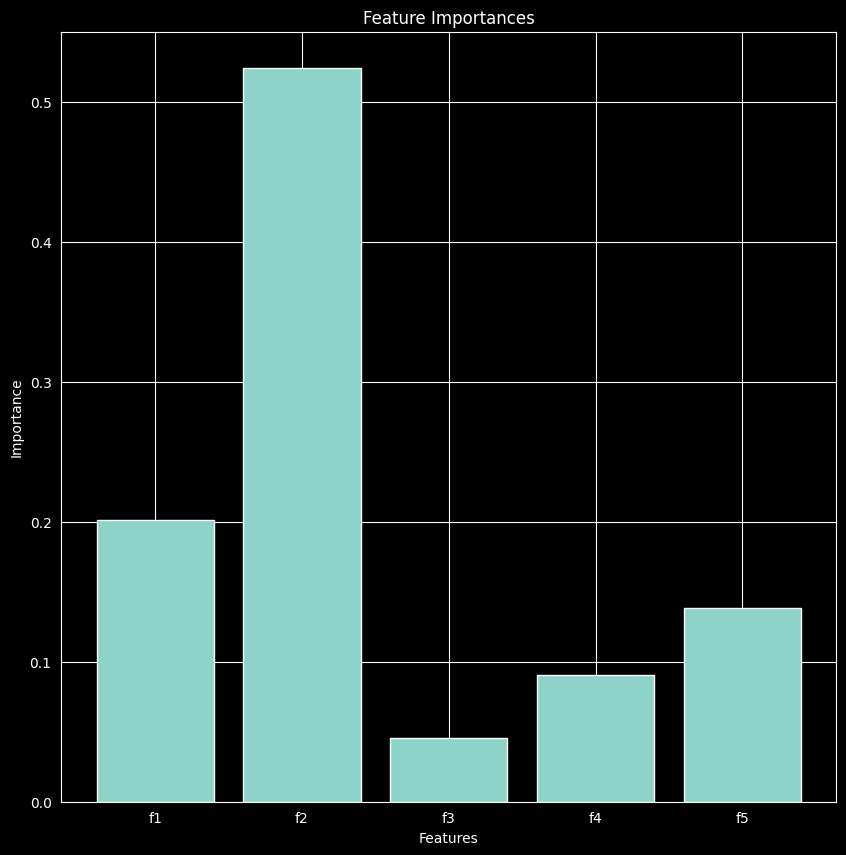

In [60]:
import matplotlib.pyplot as plt



plt.figure(figsize=(10,10))
plt.bar(X_train.columns , forest.feature_importances_)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importances")
plt.show()

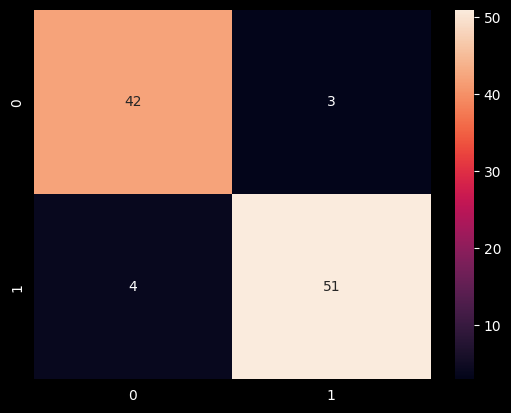

In [61]:
import seaborn as sns

sns.heatmap(cm , annot=True)